# Toolbox ML - Demo Notebook

* Notebook de demostración del Team Challenge

* Demostración de las funcionalidades implementadas en la librería Toolbox ML utilizando el dataset Titanic de Seaborn.

## Dataset utilizado

* Para la demostración utilizaremos el dataset Titanic incluido en Seaborn.

* Este conjunto de datos contiene información sobre los pasajeros del Titanic, incluyendo variables demográficas, económicas y de supervivencia, siendo ampliamente utilizado en ejemplos de análisis exploratorio y machine learning.

In [10]:
import pandas as pd
import seaborn as sns
import warnings

warnings.simplefilter("ignore", FutureWarning)

from toolbox_ml.eda.core import (
    describe_df,
    tipifica_variables,
    get_features_num_regression,
    plot_features_num_regression,
    get_features_cat_regression,
    plot_features_cat_regression
)

In [11]:
df = sns.load_dataset("titanic")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Información general del dataset

Antes de utilizar las funciones de la librería, observamos las dimensiones del dataset

In [12]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 891
Columnas: 15


## 1. describe_df()

Esta función genera un resumen descriptivo del dataset, mostrando información útil como:

- Tipo de dato de cada columna.
- Porcentaje de valores nulos.
- Número de valores únicos.
- Cardinalidad de las variables.

Es una herramienta útil para obtener una visión general rápida del dataset antes de comenzar el análisis.

In [13]:
describe_df(df).round(2)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
survived,int64,0.00,2,0.22
pclass,int64,0.00,3,0.34
sex,object,0.00,2,0.22
age,float64,19.87,88,9.88
sibsp,int64,0.00,7,0.79
parch,int64,0.00,7,0.79
fare,float64,0.00,248,27.83
embarked,object,0.22,3,0.34
class,category,0.00,3,0.34
who,object,0.00,3,0.34


## 2. tipifica_variables()

Esta función clasifica automáticamente las variables según su naturaleza:

- Binarias.
- Categóricas.
- Numéricas discretas.
- Numéricas continuas.

La clasificación ayuda a decidir qué tipo de análisis o visualización es más adecuada para cada variable.

In [14]:
tipifica_variables(
    df,
    umbral_categoria=10,
    umbral_continua=20.0
)

,nombre_variable,tipo_sugerido
0,survived,Binaria
1,pclass,Categórica
2,sex,Binaria
3,age,Numérica Discreta
4,sibsp,Categórica
5,parch,Categórica
6,fare,Numérica Continua
7,embarked,Categórica
8,class,Categórica
9,who,Categórica


# 3. get_features_num_regression()

Buscamos variables numéricas que presenten relación con la variable objetivo **age**.

La función utiliza la correlación de Pearson y permite filtrar las variables según un umbral mínimo de correlación.

In [15]:
get_features_num_regression(
    df=df,
    target_col="age",
    umbral_corr=0.2
)

['pclass', 'sibsp']

# 4. plot_features_num_regression()

Una vez identificadas las variables numéricas relacionadas con la edad, generamos visualizaciones para analizar gráficamente dichas relaciones.

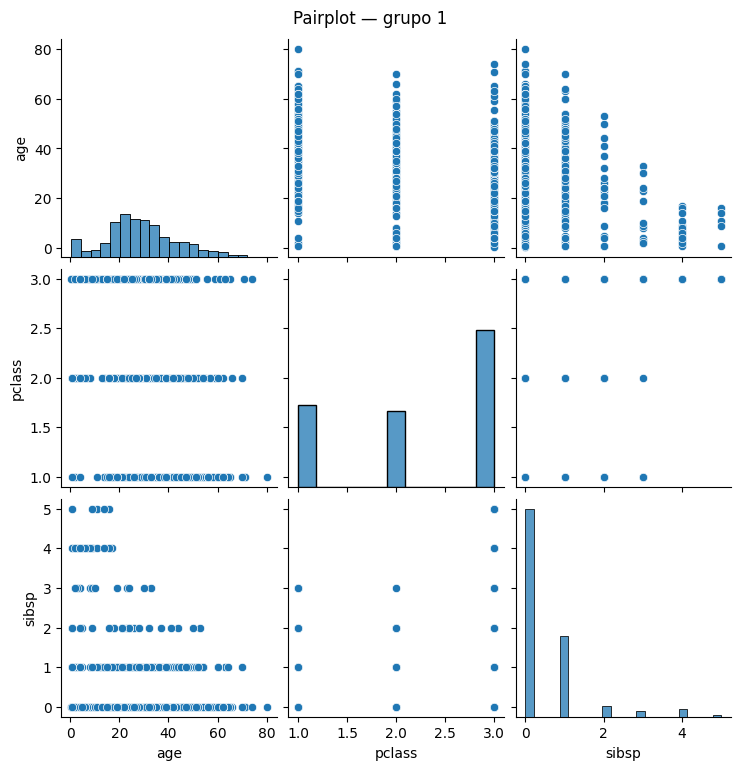

['pclass', 'sibsp']

In [16]:
plot_features_num_regression(
    df=df,
    target_col="age",
    umbral_corr=0.2
)

# 5. get_features_cat_regression()

Analizamos qué variables categóricas presentan diferencias significativas respecto a la variable objetivo **age**.

La función utiliza pruebas estadísticas para detectar relaciones relevantes entre categorías y variables numéricas.

In [17]:
get_features_cat_regression(
    df=df,
    target_col="age",
    pvalue=0.05
)

['sex', 'class', 'who', 'adult_male', 'deck', 'alone']

# 6. plot_features_cat_regression()

Visualizamos las variables categóricas identificadas previamente para interpretar de forma más sencilla cómo se distribuye la variable objetivo entre los distintos grupos.

La función genera automáticamente representaciones gráficas que facilitan la comparación entre categorías.

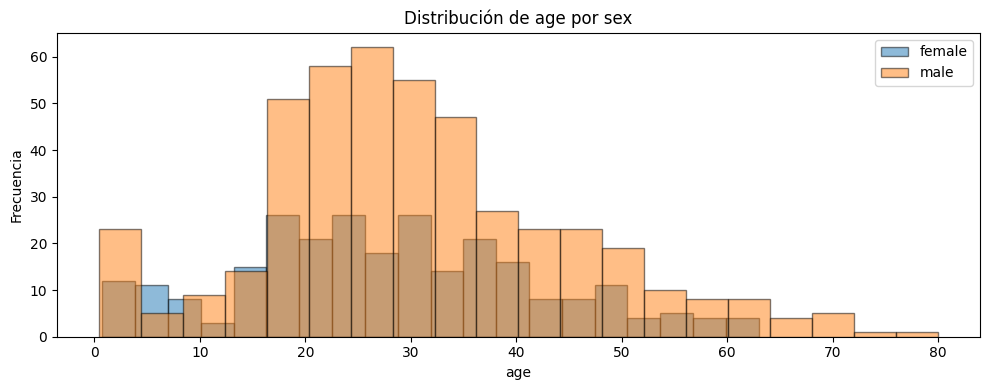

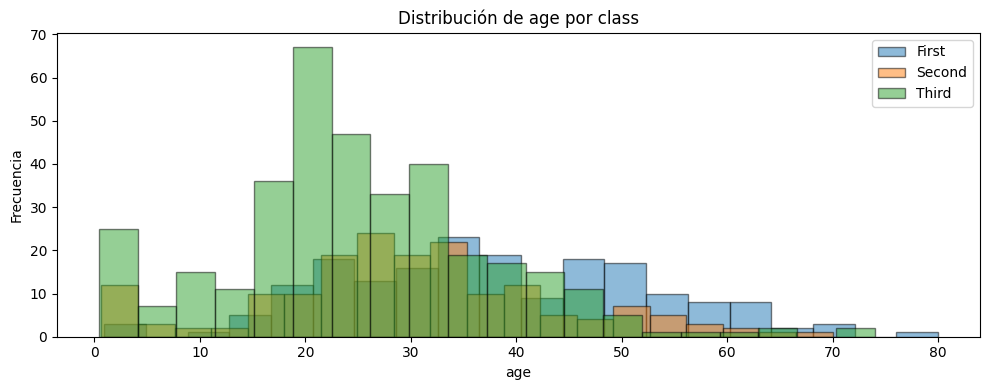

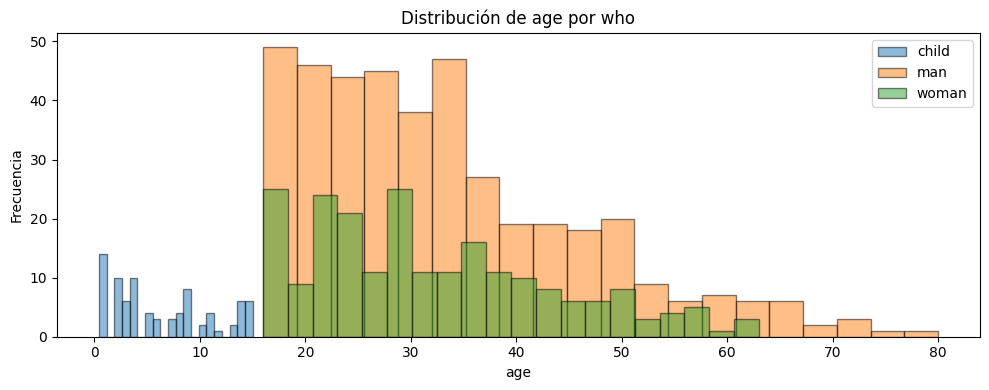

['sex', 'class', 'who']

In [19]:
plot_features_cat_regression(
    df=df,
    target_col="age",
    columns=["sex", "class", "who"],
    pvalue=0.05
)

# Resumen de resultados obtenidos

Utilizando el dataset Titanic:

- Se identificaron 2 variables numéricas relacionadas con la edad: pclass y sibsp.
- Se identificaron 6 variables categóricas relacionadas con la edad: sex, class, who, adult_male, deck y alone.
- Las visualizaciones permitieron validar gráficamente las relaciones encontradas.

Esto demuestra el funcionamiento completo de las herramientas implementadas en Toolbox ML.

# Conclusiones

La librería Toolbox ML permite automatizar tareas habituales de Análisis Exploratorio de Datos (EDA) y selección de variables.

Durante esta demostración se han utilizado las seis funciones implementadas sobre el dataset Titanic de Seaborn, mostrando su utilidad para:

* Describir datasets.
* Tipificar variables.
* Identificar relaciones numéricas.
* Visualizar relaciones numéricas.
* Identificar relaciones categóricas.
* Visualizar relaciones categóricas.

Todas las funcionalidades han sido desarrolladas siguiendo buenas prácticas de ingeniería de software, documentadas en GitHub y validadas mediante pruebas unitarias automatizadas.
